<a href="https://colab.research.google.com/github/ThienPhu2708/2001230673_PhungDuongThienPhu_THDeepLearning_Buoi2/blob/main/2001230673_PhungDuongThienPhu_Buoi02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Vòng lặp (Epoch) 1/20 ---
   [EarlyStop] val_loss hiện tại: 0.65798 | Khởi tạo best_loss = 0.65798

--- Vòng lặp (Epoch) 2/20 ---
   [EarlyStop] val_loss hiện tại: 0.53828 | Tuyệt vời! best_loss giảm từ 0.65798 xuống 0.53828. Reset Counter về 0.

--- Vòng lặp (Epoch) 3/20 ---
   [EarlyStop] val_loss hiện tại: 0.43681 | Tuyệt vời! best_loss giảm từ 0.53828 xuống 0.43681. Reset Counter về 0.

--- Vòng lặp (Epoch) 4/20 ---
   [EarlyStop] val_loss hiện tại: 0.35456 | Tuyệt vời! best_loss giảm từ 0.43681 xuống 0.35456. Reset Counter về 0.

--- Vòng lặp (Epoch) 5/20 ---
   [EarlyStop] val_loss hiện tại: 0.29001 | Tuyệt vời! best_loss giảm từ 0.35456 xuống 0.29001. Reset Counter về 0.

--- Vòng lặp (Epoch) 6/20 ---
   [EarlyStop] val_loss hiện tại: 0.23839 | Tuyệt vời! best_loss giảm từ 0.29001 xuống 0.23839. Reset Counter về 0.

--- Vòng lặp (Epoch) 7/20 ---
   [EarlyStop] val_loss hiện tại: 0.19498 | Tuyệt vời! best_loss giảm từ 0.23839 xuống 0.19498. Reset Counter về 0.

--- Vòng lặp 

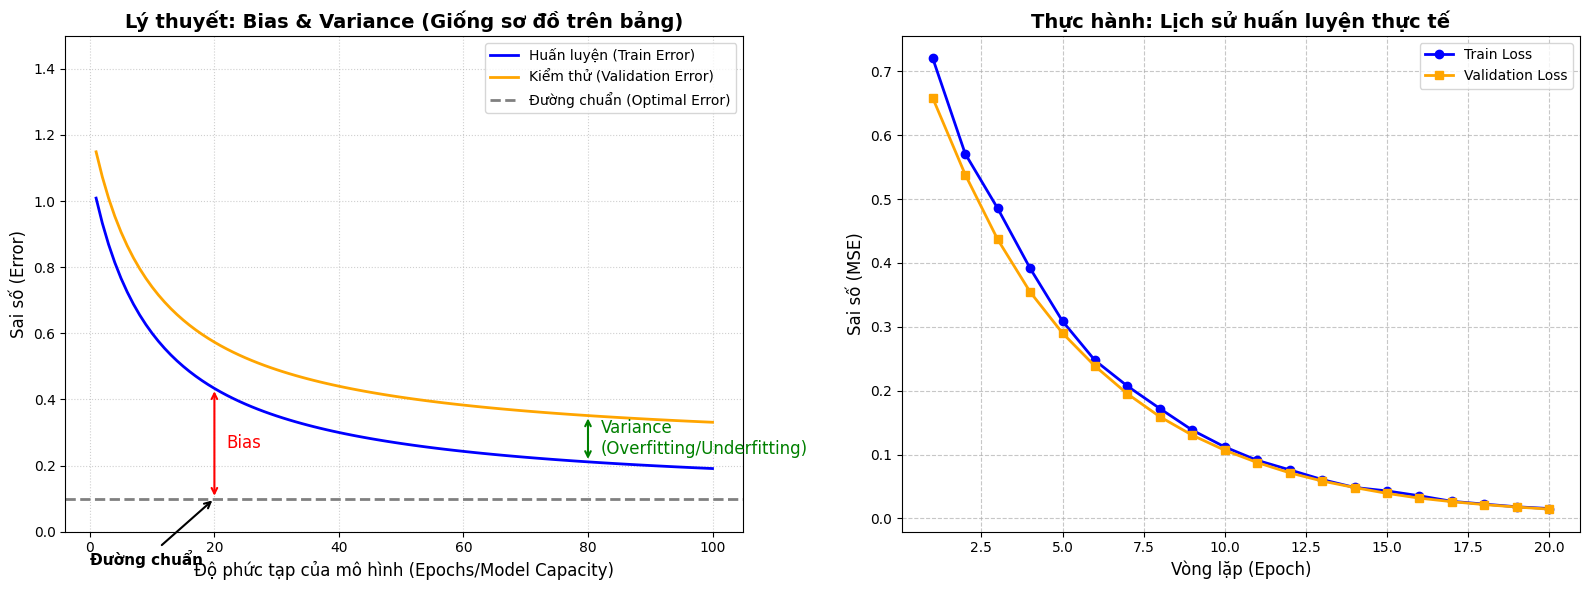

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ==========================================
# 1. LỚP EARLY STOPPING BÁO CÁO TỪNG BƯỚC
# ==========================================
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        print(f"   [EarlyStop] val_loss hiện tại: {val_loss:.5f}", end=" | ")

        if self.best_loss is None:
            self.best_loss = val_loss
            print(f"Khởi tạo best_loss = {self.best_loss:.5f}")

        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"Không cải thiện! Counter tăng: {self.counter}/{self.patience} (best_loss vẫn là {self.best_loss:.5f})")

            if self.counter >= self.patience:
                self.early_stop = True

        else:
            print(f"Tuyệt vời! best_loss giảm từ {self.best_loss:.5f} xuống {val_loss:.5f}. Reset Counter về 0.")
            self.best_loss = val_loss
            self.counter = 0

# ==========================================
# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
df = pd.read_csv('insurance.csv')
df = df.dropna()
df = df.drop_duplicates()
df = df[(df['age'] >= 20) & (df['age'] <= 30)]
df = df[(df['charges'] >= 100) & (df['charges'] <= 5000)]

le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop('charges', axis=1).values
y = df['charges'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

std_scaler = StandardScaler()
X_train_scaled = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.transform(X_test)

min_max_scaler = MinMaxScaler(feature_range=(0, 1))
y_train_scaled = min_max_scaler.fit_transform(y_train)
y_test_scaled = min_max_scaler.transform(y_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==========================================
# 3. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH
# ==========================================
model = nn.Linear(X_train_t.shape[1], 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Cài đặt giới hạn kiên nhẫn
early_stopping = EarlyStopping(patience=3, min_delta=0.001)

train_losses = []
val_losses = []
stopped_epoch = 20

epochs = 20
for epoch in range(epochs):
    model.train()
    batch_train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        batch_train_loss += loss.item()

    train_loss = batch_train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in test_loader:
            val_outputs = model(val_inputs)
            batch_loss = criterion(val_outputs, val_targets)
            val_loss += batch_loss.item()

    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    # In ra số vòng lặp để theo dõi
    print(f"\n--- Vòng lặp (Epoch) {epoch + 1}/{epochs} ---")

    # Kích hoạt Early Stopping kiểm tra
    early_stopping(val_loss)

    if early_stopping.early_stop:
        stopped_epoch = epoch + 1
        break

# Tính toán lại MSE cuối cùng
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train_t).numpy()
    y_test_pred = model(X_test_t).numpy()

train_mse = mean_squared_error(y_train_scaled, y_train_pred)
test_mse = mean_squared_error(y_test_scaled, y_test_pred)

# Retrain nếu mô hình quá tệ
if train_mse > 0.15 or (test_mse - train_mse) > 0.05:
    model_retrained = nn.Linear(X_train_t.shape[1], 1)
    optimizer_retrained = optim.SGD(model_retrained.parameters(), lr=0.05)

    for epoch in range(50):
        model_retrained.train()
        optimizer_retrained.zero_grad()
        outputs = model_retrained(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer_retrained.step()

# ==========================================
# 4. TRỰC QUAN HÓA (BIỂU ĐỒ)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x_theory = np.linspace(1, 100, 100)
baseline_error = 0.1 # Đường chuẩn
train_theory = 1 / (0.1 * x_theory + 1) + baseline_error
test_theory = 1 / (0.1 * x_theory + 1) + baseline_error + 0.14

ax1.plot(x_theory, train_theory, label='Huấn luyện (Train Error)', color='blue', linewidth=2)
ax1.plot(x_theory, test_theory, label='Kiểm thử (Validation Error)', color='orange', linewidth=2)

ax1.axhline(y=baseline_error, color='gray', linestyle='--', linewidth=2, label='Đường chuẩn (Optimal Error)')

ax1.annotate('Đường chuẩn', xy=(20, baseline_error), xytext=(0, baseline_error - 0.2),
             arrowprops=dict(arrowstyle='->', color='black', linewidth=1.5),
             fontsize=11, fontweight='bold')

x_bias = 20
y_train_bias = train_theory[19]
ax1.annotate('', xy=(x_bias, baseline_error), xytext=(x_bias, y_train_bias),
             arrowprops=dict(arrowstyle='<->', color='red', linewidth=1.5))
ax1.text(x_bias + 2, (baseline_error + y_train_bias)/2, 'Bias', verticalalignment='center', color='red', fontsize=12)

x_var = 80
y_train_var = train_theory[79]
y_test_var = test_theory[79]
ax1.annotate('', xy=(x_var, y_train_var), xytext=(x_var, y_test_var),
             arrowprops=dict(arrowstyle='<->', color='green', linewidth=1.5))
ax1.text(x_var + 2, (y_train_var + y_test_var)/2, 'Variance\n(Overfitting/Underfitting)', verticalalignment='center', color='green', fontsize=12)

ax1.set_title('Lý thuyết: Bias & Variance (Giống sơ đồ trên bảng)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Độ phức tạp của mô hình (Epochs/Model Capacity)', fontsize=12)
ax1.set_ylabel('Sai số (Error)', fontsize=12)
ax1.set_ylim(0, 1.5)
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# --- AX2: Biểu đồ Thực hành ---
ax2.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o', color='blue', linewidth=2)
ax2.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='s', color='orange', linewidth=2)

if early_stopping.early_stop:
    ax2.axvline(x=stopped_epoch, color='red', linestyle='--', label=f'Early Stop (Epoch {stopped_epoch})')

ax2.set_title('Thực hành: Lịch sử huấn luyện thực tế', fontsize=14, fontweight='bold')
ax2.set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax2.set_ylabel('Sai số (MSE)', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()